<a href="https://colab.research.google.com/github/VasilisPapageorgiou/Amortization-of-Risk-Indicators/blob/main/Amortization_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

1 = RESUME latest run
2 = START NEW run from zero
Choose 1 or 2: 1
ROOT: /content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602
Signature: 9b257f151145d32a
Device: cpu | exact workers: 2
TRAIN: full cache loaded (100,000)
VALIDATION: full cache loaded (500)
TEST_SEEN: full cache loaded (500)
TEST_INTERP: full cache loaded (450)
TRAIN: n=100,000, tau valid=98,895/100,000
VALIDATION: n=500, tau valid=494/500
TEST SEEN: n=500, tau valid=495/500
TEST INTERP: n=450, tau valid=444/450

REPETITION 1/5
rep01_R20000 | complete — skipping
rep01_R30000 | complete — skipping
rep01_R50000 | complete — skipping
rep01_R100000 | complete — skipping

REPETITION 2/5
rep02_R20000 | complete — skipping
rep02_R30000 | complete — skipping
rep02_R50000 | complete — skipping
rep02_R100000 | complete — skipping

REPETITION 3/5
rep03_R20000 | complete — skipping
rep03_R30000 | complete — skipping
rep03_R50000 | complete — skipping
rep03_R100000 | com

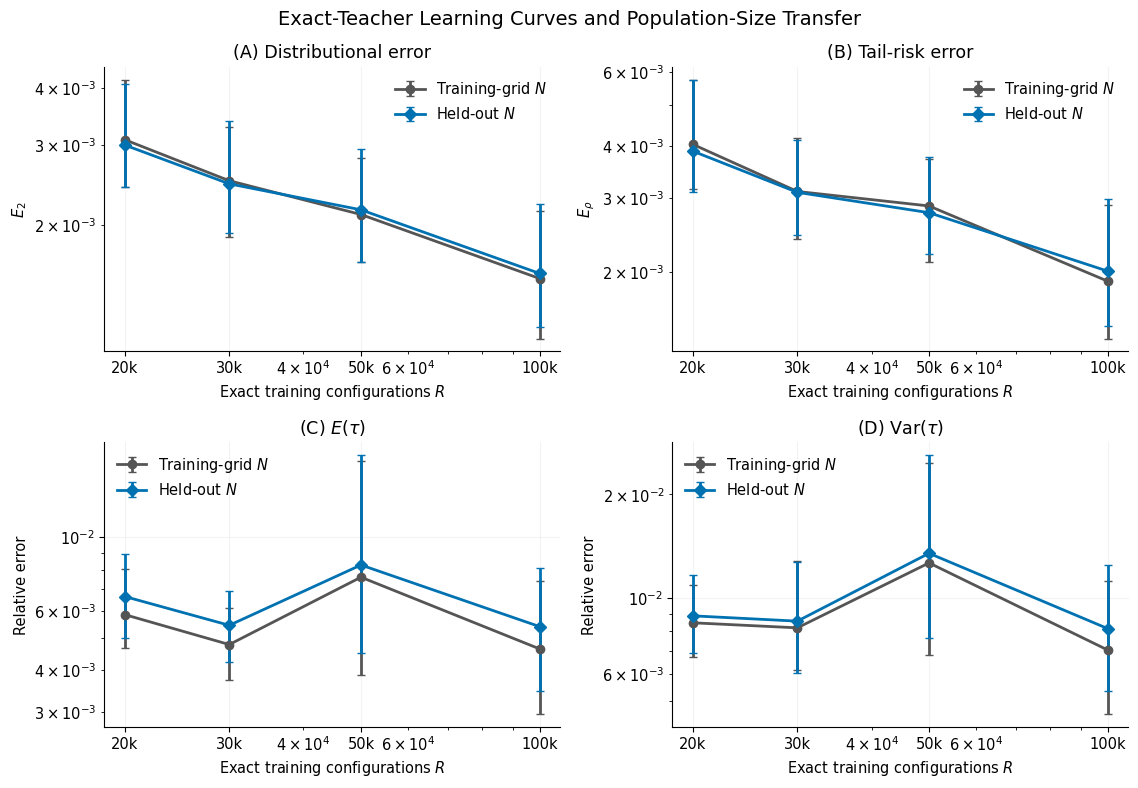


5.1-B COMPLETE
Run: /content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602
R: (20000, 30000, 50000, 100000)
Replications: 5
Training pool: 100,000
Seen-N test: 500
Interpolation test: 450

Main table:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/main_table_5_1B.tex

Main figure:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/figure_5_1B_main.pdf

Additional diagnostics:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/full_numeric_summary.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/raw_test_errors.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/robustness_by_stratum.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/transfer_penalty.csv
/co

In [2]:
# =====================================================================================
# EXPERIMENT 5.1-B — HIGH-R EXACT-TEACHER LEARNING CURVE
# FINAL / RESUMABLE / PUBLICATION VERSION
#
# R = 20k, 30k, 50k, 100k
#
# 5 independent repetitions.
# Within each repetition:
#   D_20k ⊂ D_30k ⊂ D_50k ⊂ D_100k
#
# Main outputs:
#   main_table_5_1B.tex
#   figure_5_1B_main.pdf
#
# Additional:
#   full_numeric_summary.csv
#   raw_test_errors.csv
#   robustness_by_stratum.csv
#   transfer_penalty.csv
#   training_diagnostics.csv
#
# Exact targets and neural fits are permanently checkpointed on Google Drive.
# =====================================================================================


# =====================================================================================
# 0. DRIVE + IMPORTS
# =====================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from __future__ import annotations

import os, json, math, pickle, random, hashlib, time
from dataclasses import dataclass, asdict
from datetime import datetime
from functools import lru_cache
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.sparse.linalg import splu
from scipy.stats import qmc
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =====================================================================================
# 1. CONFIG
# =====================================================================================

@dataclass
class Config:
    seed:int = 20260820

    beta_range:Tuple[float,float] = (.30,1.50)
    gamma_range:Tuple[float,float] = (.20,1.00)
    omega_range:Tuple[float,float] = (.02,.50)
    frac_range:Tuple[float,float] = (.02,.20)
    i0_one_fraction:float = .25

    train_N:Tuple[int,...] = (30,50,70,90,110,130,150)
    interp_N:Tuple[int,...] = (40,60,80,100,120,140)

    n_train:int = 100000
    n_val:int = 500
    n_test_seen:int = 500
    n_test_interp:int = 450

    width:int = 128
    depth:int = 3
    batch:int = 64
    epochs:int = 500

    lr:float = 1e-3
    wd:float = 1e-6

    lambda_rho:float = 1.
    lambda_tau:float = .02

    patience:int = 20
    min_delta:float = 1e-6
    clip:float = 5.

    prob_tol:float = 1e-10
    var_rel_tol:float = 1e-8
    kl_eps:float = 1e-12
    refine_steps:int = 3


cfg = Config()

R_VALUES = (20000,30000,50000,100000)
N_REP = 5

BOOT_B = 3000
EXACT_CHUNK = 200
BATCH_CHECKPOINT_EVERY = 50

SEEN_N = cfg.train_N
INTERP_N = cfg.interp_N

assert max(R_VALUES) == cfg.n_train
assert set(SEEN_N).isdisjoint(INTERP_N)

N_SCALE = max(cfg.train_N)


# =====================================================================================
# 2. RUN PROTECTION
#
# Increment manually if you change scientific implementation:
# exact solver / loss / network / design logic / evaluation definitions.
# =====================================================================================

CODE_VERSION = "5.1B_highR_JASA_v1"

SCIENTIFIC_CONFIG = {
    "code_version":CODE_VERSION,
    "config":asdict(cfg),
    "R_VALUES":R_VALUES,
    "N_REP":N_REP,
    "bootstrap":BOOT_B,
    "design":"balanced nested subsets within repetition",
    "initialization":"common initialization across R within repetition"
}

def signature(x):
    s=json.dumps(x,sort_keys=True,default=str)
    return hashlib.sha256(s.encode()).hexdigest()[:16]

SIG = signature(SCIENTIFIC_CONFIG)

BASE = Path(
    "/content/drive/MyDrive/StatisticalLearning/"
    "Experiment_5_1B_highR_JASA"
)
BASE.mkdir(parents=True,exist_ok=True)

print("\n"+"="*80)
print("1 = RESUME latest run")
print("2 = START NEW run from zero")
print("="*80)

mode=input("Choose 1 or 2: ").strip()
if mode not in ("1","2"):
    raise RuntimeError("Choose 1 or 2.")

latest=BASE/"latest_run.txt"

if mode=="2":
    stamp=datetime.now().strftime("%Y%m%d_%H%M%S")
    ROOT=BASE/f"run_{stamp}"
    ROOT.mkdir()

    with open(ROOT/"manifest.pkl","wb") as f:
        pickle.dump(
            {"signature":SIG,
             "scientific_config":SCIENTIFIC_CONFIG},
            f,pickle.HIGHEST_PROTOCOL
        )

    latest.write_text(ROOT.name)

else:
    if not latest.exists():
        raise RuntimeError("No run exists. Choose START NEW.")

    ROOT=BASE/latest.read_text().strip()
    mf=ROOT/"manifest.pkl"

    if not mf.exists():
        raise RuntimeError("Missing manifest; resume is unsafe.")

    with open(mf,"rb") as f:
        old=pickle.load(f)

    if old["signature"] != SIG:
        raise RuntimeError(
            "\nScientific specification changed.\n"
            "RESUME aborted. Choose START NEW."
        )


CACHE=ROOT/"cache"
EXACT=CACHE/"exact"
MODELS=CACHE/"models"
CKPT=CACHE/"checkpoints"
OUT=ROOT/"results"

for d in (CACHE,EXACT,MODELS,CKPT,OUT):
    d.mkdir(parents=True,exist_ok=True)

print("ROOT:",ROOT)
print("Signature:",SIG)


# =====================================================================================
# 3. UTILITIES
# =====================================================================================

def atomic_pickle(x,path):
    path=Path(path); tmp=path.with_suffix(path.suffix+".tmp")
    with open(tmp,"wb") as f:
        pickle.dump(x,f,pickle.HIGHEST_PROTOCOL)
    os.replace(tmp,path)

def atomic_torch(x,path):
    path=Path(path); tmp=path.with_suffix(path.suffix+".tmp")
    torch.save(x,tmp); os.replace(tmp,path)

def load_pickle(path,default=None):
    try:
        with open(path,"rb") as f:
            return pickle.load(f)
    except Exception:
        return default

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

seed_all(cfg.seed)

try:
    torch.use_deterministic_algorithms(True,warn_only=True)
except Exception:
    pass

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

CPU=os.cpu_count() or 1
N_EXACT=max(1,min(2,CPU))

if device.type=="cpu":
    torch.set_num_threads(max(1,min(8,CPU)))

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print("Device:",device,"| exact workers:",N_EXACT)


# =====================================================================================
# 4. EXACT SIRS TEACHER
# =====================================================================================

@lru_cache(None)
def topology(N):
    states=[(s,i) for i in range(1,N+1) for s in range(N-i+1)]
    ix={x:j for j,x in enumerate(states)}
    M=len(states)

    ir=[];ic=[];ib=[]
    rr=[];rc=[];rb=[]
    wr=[];wc=[];wb=[]

    db=np.zeros(M); dg=np.zeros(M); dw=np.zeros(M); qb=np.zeros(M)

    for j,(s,i) in enumerate(states):
        r=N-s-i

        if s:
            ir.append(j); ic.append(ix[(s-1,i+1)])
            rate=s*i/N
            ib.append(rate); db[j]=rate

        dg[j]=i
        if i==1:
            qb[j]=i
        else:
            rr.append(j); rc.append(ix[(s,i-1)]); rb.append(i)

        if r:
            wr.append(j); wc.append(ix[(s+1,i)]); wb.append(r); dw[j]=r

    A=lambda x,d=float:np.asarray(x,dtype=d)

    return (
        ix,M,
        A(ir,int),A(ic,int),A(ib),
        A(rr,int),A(rc,int),A(rb),
        A(wr,int),A(wc,int),A(wb),
        db,dg,dw,qb
    )


def matrices(beta,gamma,omega,N):
    (ix,M,ir,ic,ib,rr,rc,rb,wr,wc,wb,db,dg,dw,qb)=topology(N)

    rows=np.r_[ir,rr,wr,np.arange(M)]
    cols=np.r_[ic,rc,wc,np.arange(M)]

    vals=np.r_[
        beta*ib,gamma*rb,omega*wb,
        -(beta*db+gamma*dg+omega*dw)
    ]

    T=sparse.coo_matrix(
        (vals,(rows,cols)),shape=(M,M),dtype=np.float64
    ).tocsc()

    D1=sparse.coo_matrix(
        (beta*ib,(ir,ic)),shape=(M,M),dtype=np.float64
    ).tocsc()

    return T,(T-D1).tocsc(),D1,gamma*qb,ix


def refined(A,lu,b,trans=False):
    b=np.asarray(b,dtype=np.float64)
    mode="T" if trans else "N"
    x=lu.solve(b,trans=mode)

    for _ in range(cfg.refine_steps):
        r=b-(A.T@x if trans else A@x)
        if not np.all(np.isfinite(r)): break
        rel=np.linalg.norm(r,np.inf)/max(np.linalg.norm(b,np.inf),1.)
        if rel<1e-11: break
        x+=lu.solve(r,trans=mode)

    return np.asarray(x,dtype=np.float64)


def moment_factor(A,ordering):
    d=np.abs(A.diagonal())
    scale=1./np.maximum(d,np.finfo(float).tiny)
    As=(sparse.diags(scale)@A).tocsc()
    return splu(As,permc_spec=ordering),scale


def moment_solve(A,lu,scale,b):
    b=np.asarray(b,dtype=np.float64)
    x=lu.solve(scale*b)

    for _ in range(cfg.refine_steps):
        r=b-A@x
        if not np.all(np.isfinite(r)): break
        rel=np.linalg.norm(r,np.inf)/max(np.linalg.norm(b,np.inf),1.)
        if rel<1e-11: break
        x+=lu.solve(scale*r)

    return np.asarray(x,dtype=np.float64)


def variance_system(T,q,A,lu,scale,m1):
    C=T.tocoo()
    keep=C.row!=C.col
    rr,cc,rates=C.row[keep],C.col[keep],C.data[keep]

    source=np.bincount(
        rr,
        weights=rates*(m1[cc]-m1[rr])**2,
        minlength=T.shape[0]
    ).astype(float)

    source+=q*m1*m1

    if not np.all(np.isfinite(source)) or source.min()<-1e-8:
        raise ArithmeticError("Invalid variance RHS.")

    return moment_solve(A,lu,scale,np.maximum(source,0.))


def extinction_moments(T,q,initial):
    A=(-T).tocsc()
    one=np.ones(A.shape[0])

    errors=[]

    for ordering in ("COLAMD","MMD_AT_PLUS_A"):
        try:
            lu,scale=moment_factor(A,ordering)

            m1=moment_solve(A,lu,scale,one)
            mean=float(m1[initial])

            if not np.all(np.isfinite(m1)) or mean<=0:
                raise ArithmeticError("Invalid extinction mean.")

            m2=moment_solve(A,lu,scale,2*m1)
            second=float(m2[initial])

            if not np.all(np.isfinite(m2)) or second<=0:
                raise ArithmeticError("Invalid second moment.")

            raw=np.longdouble(second)-np.longdouble(mean)**2
            tol=cfg.var_rel_tol*max(abs(second),mean*mean,1.)

            if np.isfinite(raw) and raw>=-tol:
                var=max(float(raw),0.)
                method="subtraction"
            else:
                vv=variance_system(T,q,A,lu,scale,m1)
                var=float(vv[initial])
                method="variance-system"

            if not np.isfinite(var) or var<0:
                raise ArithmeticError("Invalid extinction variance.")

            return mean,second,var,True,f"{ordering}; {method}"

        except Exception as e:
            errors.append(f"{ordering}: {e}")

    return np.nan,np.nan,np.nan,False," | ".join(errors)


def exact_targets(beta,gamma,omega,N,i0):
    T,D0,D1,q,ix=matrices(beta,gamma,omega,N)
    M=T.shape[0]
    initial=ix[(N-i0,i0)]

    A0=(-D0).tocsc()
    lu=splu(A0,permc_spec="COLAMD")

    v=np.zeros(M); v[initial]=1.
    b=refined(A0,lu,q)

    p=np.zeros(N+2)

    for k in range(N+1):
        p[k]=v@b
        y=refined(A0,lu,v,trans=True)
        v=np.asarray(D1.T@y).ravel()

    p[-1]=v.sum()
    p[np.abs(p)<cfg.prob_tol]=0.

    if not np.all(np.isfinite(p)) or p.min()<-cfg.prob_tol:
        raise RuntimeError("Invalid exact PMF.")

    p=np.maximum(p,0.)
    mass=p.sum()

    if not np.isfinite(mass) or abs(mass-1.)>1e-5:
        raise RuntimeError(f"Invalid mass={mass}.")

    p/=mass

    m,m2,var,ok,info=extinction_moments(T,q,initial)

    return p,m,m2,var,ok,info


# =====================================================================================
# 5. DESIGN + EXACT CACHE
# =====================================================================================

@dataclass
class Record:
    beta:float; gamma:float; omega:float
    N:int; i0:int
    p:np.ndarray
    mean_tau:float; second_tau:float; var_tau:float
    tau_valid:bool; tau_info:str


def stretch(x,a):
    return a[0]+(a[1]-a[0])*x


def design(n,Ns,seed):
    U=qmc.LatinHypercube(d=4,seed=seed).random(n)

    beta=stretch(U[:,0],cfg.beta_range)
    gamma=stretch(U[:,1],cfg.gamma_range)
    omega=stretch(U[:,2],cfg.omega_range)
    frac=stretch(U[:,3],cfg.frac_range)

    Nv=np.tile(np.asarray(Ns),math.ceil(n/len(Ns)))[:n]
    rng=np.random.default_rng(seed+991)
    rng.shuffle(Nv)

    i0=np.array([
        int(np.clip(round(frac[j]*Nv[j]),2,Nv[j]))
        for j in range(n)
    ])

    for N in Ns:
        z=np.where(Nv==N)[0]
        if len(z):
            k=max(1,round(cfg.i0_one_fraction*len(z)))
            i0[rng.choice(z,k,replace=False)]=1

    return [
        (float(beta[j]),float(gamma[j]),float(omega[j]),
         int(Nv[j]),int(i0[j]))
        for j in range(n)
    ]


def matches(records,configs,tol=1e-12):
    if records is None or len(records)!=len(configs):
        return False

    for r,x in zip(records,configs):
        b,g,w,N,i0=x
        if (
            abs(r.beta-b)>tol or abs(r.gamma-g)>tol or
            abs(r.omega-w)>tol or r.N!=N or r.i0!=i0
        ):
            return False

    return True


def exact_one(j,x):
    b,g,w,N,i0=x
    p,m,m2,v,ok,info=exact_targets(*x)
    return j,Record(b,g,w,N,i0,p,m,m2,v,ok,info)


def exact_set(configs,name):
    full=EXACT/f"{name}_full.pkl"

    if full.exists():
        z=load_pickle(full)
        if matches(z,configs):
            print(f"{name}: full cache loaded ({len(z):,})")
            return z

    folder=EXACT/name
    folder.mkdir(parents=True,exist_ok=True)

    ans=[]

    for start in range(0,len(configs),EXACT_CHUNK):
        end=min(start+EXACT_CHUNK,len(configs))
        cc=configs[start:end]
        f=folder/f"chunk_{start:06d}_{end:06d}.pkl"

        part=load_pickle(f) if f.exists() else None

        if not matches(part,cc):
            jobs=list(enumerate(cc))
            jobs.sort(key=lambda z:z[1][3],reverse=True)

            t0=time.perf_counter()

            out=Parallel(
                n_jobs=N_EXACT,backend="threading"
            )(
                delayed(exact_one)(j,x)
                for j,x in jobs
            )

            out.sort(key=lambda z:z[0])
            part=[r for _,r in out]
            atomic_pickle(part,f)

            print(
                f"{name} {start:6d}:{end:6d} | "
                f"{time.perf_counter()-t0:.1f}s | saved"
            )

        else:
            print(f"{name} {start:6d}:{end:6d} | cache")

        ans.extend(part)

    if not matches(ans,configs):
        raise RuntimeError(f"{name}: cache/design mismatch.")

    atomic_pickle(ans,full)
    return ans


# =====================================================================================
# 6. GENERATE EXACT POOL
#
# One fixed 100k pool. Learning-curve repetitions differ only through balanced
# nested subset selection and optimization seed.
# =====================================================================================

train_design=design(cfg.n_train,cfg.train_N,cfg.seed+1)
val_design=design(cfg.n_val,cfg.train_N,cfg.seed+2)
seen_design=design(cfg.n_test_seen,SEEN_N,cfg.seed+3)
interp_design=design(cfg.n_test_interp,INTERP_N,cfg.seed+4)

train=exact_set(train_design,"TRAIN")
valid=exact_set(val_design,"VALIDATION")
test_seen=exact_set(seen_design,"TEST_SEEN")
test_interp=exact_set(interp_design,"TEST_INTERP")


def audit(data,name):
    if any(
        (not np.all(np.isfinite(r.p))) or abs(r.p.sum()-1)>1e-6
        for r in data
    ):
        raise RuntimeError(f"Invalid probability target in {name}.")

    print(
        f"{name}: n={len(data):,}, "
        f"tau valid={sum(r.tau_valid for r in data):,}/{len(data):,}"
    )

for data,name in (
    (train,"TRAIN"),(valid,"VALIDATION"),
    (test_seen,"TEST SEEN"),(test_interp,"TEST INTERP")
):
    audit(data,name)


# =====================================================================================
# 7. BALANCED NESTED ORDER
# =====================================================================================

def balanced_order(records,seed):
    rng=np.random.default_rng(seed)
    groups={}

    for N in cfg.train_N:
        for flag in (0,1):
            z=np.array([
                j for j,r in enumerate(records)
                if r.N==N and int(r.i0==1)==flag
            ],dtype=int)

            rng.shuffle(z)
            groups[(N,flag)]=list(z)

    ptr={k:0 for k in groups}
    usedN={N:0 for N in cfg.train_N}
    used1=0
    order=[]

    for pos in range(len(records)):
        preferred=1 if used1<cfg.i0_one_fraction*(pos+1) else 0
        chosen=None

        for flag in (preferred,1-preferred):
            cand=[
                N for N in cfg.train_N
                if ptr[(N,flag)]<len(groups[(N,flag)])
            ]

            if cand:
                m=min(usedN[N] for N in cand)
                cand=[N for N in cand if usedN[N]==m]
                chosen=(int(rng.choice(cand)),flag)
                break

        if chosen is None:
            raise RuntimeError("Balanced order failed.")

        N,flag=chosen
        j=groups[(N,flag)][ptr[(N,flag)]]

        ptr[(N,flag)]+=1
        usedN[N]+=1
        used1+=flag
        order.append(j)

    return np.asarray(order,dtype=int)


# =====================================================================================
# 8. NETWORKS + VECTORIZED PACKING
# =====================================================================================

def mlp(din,dout):
    layers=[]; d=din

    for _ in range(cfg.depth):
        layers += [nn.Linear(d,cfg.width),nn.SiLU()]
        d=cfg.width

    layers.append(nn.Linear(d,dout))
    return nn.Sequential(*layers)


class HazardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=mlp(6,1)

    def forward(self,x):
        return torch.sigmoid(self.net(x).squeeze(-1))


class TauNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=mlp(5,2)

    def forward(self,x):
        return torch.nn.functional.softplus(self.net(x))


def pack(records):
    groups={}

    for j,r in enumerate(records):
        groups.setdefault(r.N,[]).append(j)

    P={}

    for N,idx in groups.items():
        idx=np.asarray(idx,dtype=int)
        rr=[records[j] for j in idx]

        B=len(rr); K=N+1

        b=torch.tensor([r.beta for r in rr],dtype=torch.float32)[:,None]
        g=torch.tensor([r.gamma for r in rr],dtype=torch.float32)[:,None]
        w=torch.tensor([r.omega for r in rr],dtype=torch.float32)[:,None]
        ns=torch.full((B,1),N/N_SCALE,dtype=torch.float32)
        i0=torch.tensor([r.i0/N for r in rr],dtype=torch.float32)[:,None]
        c=(torch.arange(K,dtype=torch.float32)/N)[None,:]

        Xh=torch.stack([
            b.expand(B,K),g.expand(B,K),w.expand(B,K),
            ns.expand(B,K),i0.expand(B,K),c.expand(B,K)
        ],dim=2).contiguous()

        Yp=torch.from_numpy(
            np.stack([r.p for r in rr]).astype(np.float32)
        )

        Xt=torch.column_stack([
            b[:,0],g[:,0],w[:,0],ns[:,0],i0[:,0]
        ]).contiguous()

        mask=torch.tensor([r.tau_valid for r in rr],dtype=torch.bool)

        Yt=np.zeros((B,2),dtype=np.float32)
        for j,r in enumerate(rr):
            if r.tau_valid:
                Yt[j]=np.log1p([r.mean_tau,r.var_tau])

        P[N]={
            "Xh":Xh,
            "Yp":Yp,
            "Xt":Xt,
            "Yt":torch.from_numpy(Yt),
            "mask":mask,
            "orig":idx,
            "n":B
        }

    return P


def pmf_from_h(h):
    B=h.shape[0]

    before=torch.cat([
        torch.ones((B,1),dtype=h.dtype,device=h.device),
        torch.cumprod(1-h[:,:-1],dim=1)
    ],dim=1)

    return torch.cat([
        before*h,
        torch.prod(1-h,dim=1,keepdim=True)
    ],dim=1)


def tail(P):
    return torch.flip(
        torch.cumsum(
            torch.flip(P[:,1:],dims=[1]),
            dim=1
        ),
        dims=[1]
    )


def pred_p(hnet,X):
    B,K,_=X.shape
    h=hnet(X.reshape(B*K,6)).reshape(B,K)
    return pmf_from_h(h)


def batch_loss(hnet,tnet,G,idx):
    X=G["Xh"][idx].to(device)
    Y=G["Yp"][idx].to(device)

    P=pred_p(hnet,X)

    lp=torch.sum((P-Y)**2,dim=1).mean()

    lrho=torch.mean(
        (tail(P)-tail(Y))**2,
        dim=1
    ).mean()

    valid=G["mask"][idx]

    if torch.any(valid):
        Xt=G["Xt"][idx][valid].to(device)
        Yt=G["Yt"][idx][valid].to(device)

        Z=tnet(Xt)

        lt=torch.sum(
            (Z-Yt)**2/(1+Yt*Yt),
            dim=1
        ).mean()
    else:
        lt=torch.zeros((),device=device)

    return lp+cfg.lambda_rho*lrho+cfg.lambda_tau*lt,lp,lrho,lt


def batch_jobs(P,rng,shuffle=True):
    jobs=[]

    for N,G in P.items():
        idx=np.arange(G["n"])

        if shuffle:
            rng.shuffle(idx)

        for s in range(0,len(idx),cfg.batch):
            jobs.append((N,idx[s:s+cfg.batch]))

    if shuffle:
        rng.shuffle(jobs)

    return jobs


@torch.no_grad()
def validation(h,t,P):
    h.eval(); t.eval()
    rng=np.random.default_rng(1)

    total=0.; n=0

    for N,idx in batch_jobs(P,rng,False):
        L,*_=batch_loss(h,t,P[N],idx)
        total+=L.item()*len(idx)
        n+=len(idx)

    return total/n


VAL=pack(valid)


# =====================================================================================
# 9. RESUMABLE TRAINING — MID-EPOCH CHECKPOINTS
# =====================================================================================

def cpu_state(state):
    return {k:v.detach().cpu() for k,v in state.items()}


def fit(TR,rep,R):
    name=f"rep{rep:02d}_R{R}"
    final=MODELS/f"{name}_FINAL.pt"
    checkpoint=CKPT/f"{name}_CHECKPOINT.pt"

    h=HazardNet().to(device)
    t=TauNet().to(device)

    if final.exists():
        z=torch.load(final,map_location=device,weights_only=False)
        h.load_state_dict(z["h"]); t.load_state_dict(z["t"])
        print(name,"| final model loaded")
        return h,t,z

    # same initialization across R within repetition
    training_seed=cfg.seed+30000+100003*rep
    seed_all(training_seed)

    h=HazardNet().to(device)
    t=TauNet().to(device)

    pars=list(h.parameters())+list(t.parameters())

    opt=torch.optim.AdamW(
        pars,lr=cfg.lr,weight_decay=cfg.wd
    )

    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,factor=.5,patience=15
    )

    rng=np.random.default_rng(training_seed+7011)

    epoch0=1
    jobs_resume=None
    job_pos=0

    best=np.inf; best_epoch=0
    bh=bt=None; wait=0
    history=[]
    prev_elapsed=0.

    sums=np.zeros(4,dtype=float)
    nobs=0

    if checkpoint.exists():
        z=torch.load(checkpoint,map_location=device,weights_only=False)

        h.load_state_dict(z["h_current"])
        t.load_state_dict(z["t_current"])
        opt.load_state_dict(z["optimizer"])
        sch.load_state_dict(z["scheduler"])

        epoch0=z["epoch"]
        jobs_resume=z["jobs"]
        job_pos=z["job_pos"]

        best=z["best"]; best_epoch=z["best_epoch"]
        bh=z["best_h"]; bt=z["best_t"]; wait=z["wait"]

        history=z["history"]
        sums=np.asarray(z["sums"],dtype=float)
        nobs=z["nobs"]
        prev_elapsed=z["elapsed"]

        rng.bit_generator.state=z["rng_state"]
        torch.set_rng_state(z["torch_rng"].cpu())

        if device.type=="cuda" and z.get("cuda_rng") is not None:
            torch.cuda.set_rng_state_all(z["cuda_rng"])

        print(
            f"{name} | resume epoch={epoch0}, "
            f"job={job_pos}"
        )

    start=time.perf_counter()
    stopped=cfg.epochs

    for epoch in range(epoch0,cfg.epochs+1):
        h.train(); t.train()

        if epoch==epoch0 and jobs_resume is not None:
            jobs=jobs_resume
            start_job=job_pos
        else:
            jobs=batch_jobs(TR,rng,True)
            start_job=0
            sums=np.zeros(4,dtype=float)
            nobs=0

        for jj in range(start_job,len(jobs)):
            N,idx=jobs[jj]

            opt.zero_grad(set_to_none=True)

            L,Lp,Lr,Lt=batch_loss(h,t,TR[N],idx)

            if not torch.isfinite(L):
                raise RuntimeError(f"{name}: non-finite loss.")

            L.backward()
            torch.nn.utils.clip_grad_norm_(pars,cfg.clip)
            opt.step()

            B=len(idx)

            sums += B*np.array([
                L.item(),Lp.item(),Lr.item(),Lt.item()
            ])

            nobs += B

            next_job=jj+1

            if (
                next_job%BATCH_CHECKPOINT_EVERY==0
                and next_job<len(jobs)
            ):
                elapsed=prev_elapsed+time.perf_counter()-start

                atomic_torch({
                    "epoch":epoch,
                    "jobs":jobs,
                    "job_pos":next_job,

                    "h_current":cpu_state(h.state_dict()),
                    "t_current":cpu_state(t.state_dict()),

                    "optimizer":opt.state_dict(),
                    "scheduler":sch.state_dict(),

                    "best":best,
                    "best_epoch":best_epoch,
                    "best_h":bh,
                    "best_t":bt,
                    "wait":wait,

                    "history":history,
                    "sums":sums,
                    "nobs":nobs,

                    "rng_state":rng.bit_generator.state,
                    "torch_rng":torch.get_rng_state(),
                    "cuda_rng":(
                        torch.cuda.get_rng_state_all()
                        if device.type=="cuda" else None
                    ),

                    "elapsed":elapsed
                },checkpoint)

                print(
                    f"{name} | ep={epoch:3d} | "
                    f"batch={next_job:4d}/{len(jobs):4d} | checkpoint"
                )

        v=validation(h,t,VAL)
        sch.step(v)

        train_mean=sums/max(nobs,1)

        history.append({
            "epoch":epoch,
            "joint":train_mean[0],
            "pmf":train_mean[1],
            "tail":train_mean[2],
            "tau":train_mean[3],
            "validation":v
        })

        if bh is None or v<best-cfg.min_delta:
            best=float(v); best_epoch=epoch; wait=0
            bh=cpu_state(h.state_dict())
            bt=cpu_state(t.state_dict())
        else:
            wait+=1

        elapsed=prev_elapsed+time.perf_counter()-start

        atomic_torch({
            "epoch":epoch+1,
            "jobs":None,
            "job_pos":0,

            "h_current":cpu_state(h.state_dict()),
            "t_current":cpu_state(t.state_dict()),

            "optimizer":opt.state_dict(),
            "scheduler":sch.state_dict(),

            "best":best,
            "best_epoch":best_epoch,
            "best_h":bh,
            "best_t":bt,
            "wait":wait,

            "history":history,
            "sums":np.zeros(4),
            "nobs":0,

            "rng_state":rng.bit_generator.state,
            "torch_rng":torch.get_rng_state(),
            "cuda_rng":(
                torch.cuda.get_rng_state_all()
                if device.type=="cuda" else None
            ),

            "elapsed":elapsed
        },checkpoint)

        print(
            f"{name} | ep={epoch:3d} | "
            f"val={v:.4e} | best={best:.4e} | wait={wait}"
        )

        if wait>=cfg.patience:
            stopped=epoch
            break

        jobs_resume=None

    elapsed=prev_elapsed+time.perf_counter()-start

    h.load_state_dict(bh)
    t.load_state_dict(bt)

    payload={
        "h":bh,
        "t":bt,
        "history":history,
        "training_sec":elapsed,
        "best_validation_loss":best,
        "best_epoch":best_epoch,
        "stopped_epoch":stopped,
        "n_tau_train":sum(
            int(G["mask"].sum())
            for G in TR.values()
        )
    }

    atomic_torch(payload,final)

    if checkpoint.exists():
        checkpoint.unlink()

    print(
        f"{name} COMPLETE | "
        f"best ep={best_epoch} | "
        f"stop ep={stopped}"
    )

    return h,t,payload


# =====================================================================================
# 10. EVALUATION
# =====================================================================================

@torch.no_grad()
def evaluate(h,t,P,records):
    h.eval(); t.eval()

    n=len(records)

    out={
        k:np.full(n,np.nan,dtype=float)
        for k in (
            "E2","E_rho","E_overflow","KL",
            "mean_tau_relative_error",
            "var_tau_relative_error"
        )
    }

    for N,G in P.items():
        for s in range(0,G["n"],cfg.batch):
            e=min(s+cfg.batch,G["n"])
            loc=np.arange(s,e)
            orig=G["orig"][loc]

            X=G["Xh"][loc].to(device)
            Y=G["Yp"][loc].to(device)

            Ph=pred_p(h,X)

            out["E2"][orig]=(
                torch.linalg.vector_norm(Ph-Y,dim=1)
                .cpu().numpy()
            )

            out["E_rho"][orig]=(
                torch.max(
                    torch.abs(tail(Ph)-tail(Y)),
                    dim=1
                ).values.cpu().numpy()
            )

            out["E_overflow"][orig]=(
                torch.abs(Ph[:,-1]-Y[:,-1])
                .cpu().numpy()
            )

            Psafe=torch.clamp(Ph,min=cfg.kl_eps,max=1.)
            kl=torch.where(
                Y>0,
                Y*torch.log(Y/Psafe),
                torch.zeros_like(Y)
            ).sum(dim=1)

            out["KL"][orig]=kl.cpu().numpy()

            mask=G["mask"][loc]

            if torch.any(mask):
                Xt=G["Xt"][loc][mask].to(device)

                z=(
                    t(Xt)
                    .cpu()
                    .numpy()
                    .astype(np.float64)
                )

                mv=np.expm1(np.clip(z,0.,80.))

                valid_orig=orig[
                    mask.cpu().numpy()
                ]

                for q,j in enumerate(valid_orig):
                    r=records[int(j)]

                    out["mean_tau_relative_error"][j]=(
                        abs(mv[q,0]-r.mean_tau)
                        /
                        r.mean_tau
                    )

                    out["var_tau_relative_error"][j]=(
                        abs(mv[q,1]-r.var_tau)
                        /
                        max(r.var_tau,1e-300)
                    )

    return out


TEST_PACK={
    "seen":pack(test_seen),
    "interpolation":pack(test_interp)
}

TEST_RECORDS={
    "seen":test_seen,
    "interpolation":test_interp
}


# =====================================================================================
# 11. EXPERIMENT
# =====================================================================================

PROGRESS_FILE=ROOT/"learning_curve_progress.pkl"

progress=load_pickle(
    PROGRESS_FILE,
    {"results":{},"orders":{}}
)

if "results" not in progress:
    progress["results"]={}

if "orders" not in progress:
    progress["orders"]={}


for rep in range(1,N_REP+1):

    # one independent balanced nested order per repetition
    if rep not in progress["orders"]:
        progress["orders"][rep]=balanced_order(
            train,
            cfg.seed+20000+rep*1009
        )
        atomic_pickle(progress,PROGRESS_FILE)

    order=np.asarray(progress["orders"][rep],dtype=int)

    print("\n"+"="*90)
    print(f"REPETITION {rep}/{N_REP}")
    print("="*90)

    for R in R_VALUES:
        key=f"rep{rep:02d}_R{R}"

        if key in progress["results"]:
            print(key,"| complete — skipping")
            continue

        subset=[
            train[int(j)]
            for j in order[:R]
        ]

        counts={
            N:sum(r.N==N for r in subset)
            for N in cfg.train_N
        }

        print(
            f"\nR={R:,} | "
            f"N-count range={min(counts.values())}-{max(counts.values())} | "
            f"i0=1={sum(r.i0==1 for r in subset)/R:.1%}"
        )

        TR=pack(subset)

        h,t,meta=fit(TR,rep,R)

        result={}

        for split in ("seen","interpolation"):
            result[split]=evaluate(
                h,t,
                TEST_PACK[split],
                TEST_RECORDS[split]
            )

        progress["results"][key]={
            "rep":rep,
            "R":R,
            "seen":result["seen"],
            "interpolation":result["interpolation"],
            "training_sec":meta["training_sec"],
            "best_validation_loss":meta["best_validation_loss"],
            "best_epoch":meta["best_epoch"],
            "stopped_epoch":meta["stopped_epoch"],
            "n_tau_train":meta["n_tau_train"]
        }

        atomic_pickle(progress,PROGRESS_FILE)

        print(
            "Interpolation | "
            f"E2={np.nanmedian(result['interpolation']['E2']):.4e} | "
            f"E_rho={np.nanmedian(result['interpolation']['E_rho']):.4e}"
        )

        del TR,h,t

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# =====================================================================================
# 12. HIERARCHICAL BOOTSTRAP
#
# Level 1: independent learning-curve repetition
# Level 2: fixed exact test configuration
# =====================================================================================

METRICS=(
    "E2",
    "E_rho",
    "E_overflow",
    "KL",
    "mean_tau_relative_error",
    "var_tau_relative_error"
)


def matrix(R,split,metric):
    return np.vstack([
        progress["results"][f"rep{rep:02d}_R{R}"][split][metric]
        for rep in range(1,N_REP+1)
    ])


def hier_ci(A,B=BOOT_B,seed=1):
    A=np.asarray(A,float)
    nr,nc=A.shape
    rng=np.random.default_rng(seed)
    boot=[]

    for _ in range(B):
        ir=rng.integers(0,nr,size=nr)
        ic=rng.integers(0,nc,size=nc)
        x=A[ir][:,ic]
        z=np.nanmedian(x)

        if np.isfinite(z):
            boot.append(z)

    boot=np.asarray(boot)

    return (
        float(np.quantile(boot,.025)),
        float(np.quantile(boot,.975))
    )


summary=[]

for R in R_VALUES:
    for split in ("seen","interpolation"):
        for j,metric in enumerate(METRICS):
            A=matrix(R,split,metric)
            x=A[np.isfinite(A)]

            lo,hi=hier_ci(
                A,
                seed=cfg.seed+R+j+(
                    0 if split=="seen" else 50000
                )
            )

            summary.append({
                "R":R,
                "split":split,
                "metric":metric,
                "median":float(np.median(x)),
                "q1":float(np.quantile(x,.25)),
                "q3":float(np.quantile(x,.75)),
                "p95":float(np.quantile(x,.95)),
                "CI_low":lo,
                "CI_high":hi,
                "n":len(x)
            })


summary=pd.DataFrame(summary)

summary.to_csv(
    OUT/"full_numeric_summary.csv",
    index=False
)


# =====================================================================================
# 13. MAIN TABLE
# =====================================================================================

def S(R,split,metric):
    return summary[
        (summary.R==R)&
        (summary.split==split)&
        (summary.metric==metric)
    ].iloc[0]


def F(z):
    return (
        f"{z['median']:.4g} "
        f"[{z['CI_low']:.4g}, {z['CI_high']:.4g}]"
    )


table=[]

for R in R_VALUES:
    table.append({
        "R":R,

        "Seen E2":
            F(S(R,"seen","E2")),

        "Interpolation E2":
            F(S(R,"interpolation","E2")),

        "Seen Erho":
            F(S(R,"seen","E_rho")),

        "Interpolation Erho":
            F(S(R,"interpolation","E_rho")),

        "Interpolation Rel E(tau)":
            F(S(R,"interpolation","mean_tau_relative_error")),

        "Interpolation Rel Var(tau)":
            F(S(R,"interpolation","var_tau_relative_error"))
    })


main_table=pd.DataFrame(table)

main_table.to_csv(
    OUT/"main_table_5_1B.csv",
    index=False
)

(
    OUT/"main_table_5_1B.tex"
).write_text(
    main_table.to_latex(
        index=False,
        escape=False
    )
)


print("\n"+"="*110)
print("MAIN TABLE")
print("="*110)
print(main_table.to_string(index=False))


# =====================================================================================
# 14. RAW TEST ERRORS
# =====================================================================================

raw=[]

for rep in range(1,N_REP+1):
    for R in R_VALUES:
        key=f"rep{rep:02d}_R{R}"

        for split,records in TEST_RECORDS.items():
            z=progress["results"][key][split]

            for j,r in enumerate(records):
                row={
                    "rep":rep,
                    "R":R,
                    "split":split,
                    "index":j,
                    "N":r.N,
                    "i0":r.i0,
                    "R0":r.beta/r.gamma
                }

                for metric in METRICS:
                    row[metric]=z[metric][j]

                raw.append(row)


raw=pd.DataFrame(raw)

raw.to_csv(
    OUT/"raw_test_errors.csv",
    index=False
)


# =====================================================================================
# 15. STRATIFIED ROBUSTNESS
# =====================================================================================

raw["i0_group"]=np.where(
    raw.i0==1,
    "i0=1",
    "i0>1"
)

raw["R0_regime"]=pd.cut(
    raw.R0,
    [-np.inf,1,2,np.inf],
    labels=["R0<1","1<=R0<2","R0>=2"]
)


rob=[]

for stype,column in (
    ("initial condition","i0_group"),
    ("epidemic regime","R0_regime"),
    ("population size","N")
):
    for (R,split,level),z in raw.groupby(
        ["R","split",column],
        observed=True
    ):
        rob.append({
            "stratum_type":stype,
            "stratum":str(level),
            "R":int(R),
            "split":split,
            "n":len(z),
            "median_E2":np.nanmedian(z.E2),
            "p95_E2":np.nanquantile(z.E2,.95),
            "median_Erho":np.nanmedian(z.E_rho),
            "p95_Erho":np.nanquantile(z.E_rho,.95)
        })


pd.DataFrame(rob).to_csv(
    OUT/"robustness_by_stratum.csv",
    index=False
)


# =====================================================================================
# 16. POPULATION-SIZE TRANSFER PENALTY
#
# For each fitted network:
#
#   median(interpolation error) - median(seen-N error)
#
# Resampling is over independent training repetitions.
# =====================================================================================

def rep_boot_ci(x,B=BOOT_B,seed=1):
    x=np.asarray(x,float)
    rng=np.random.default_rng(seed)
    z=np.empty(B)

    for b in range(B):
        z[b]=np.median(
            x[
                rng.integers(
                    0,len(x),
                    size=len(x)
                )
            ]
        )

    return (
        float(np.median(x)),
        float(np.quantile(z,.025)),
        float(np.quantile(z,.975))
    )


penalty=[]

for R in R_VALUES:
    for j,metric in enumerate((
        "E2",
        "E_rho",
        "mean_tau_relative_error",
        "var_tau_relative_error"
    )):
        d=[]

        for rep in range(1,N_REP+1):
            z=progress["results"][f"rep{rep:02d}_R{R}"]

            d.append(
                np.nanmedian(z["interpolation"][metric])
                -
                np.nanmedian(z["seen"][metric])
            )

        est,lo,hi=rep_boot_ci(
            d,
            seed=cfg.seed+R+j
        )

        penalty.append({
            "R":R,
            "metric":metric,
            "interpolation_minus_seen":est,
            "CI_low":lo,
            "CI_high":hi
        })


pd.DataFrame(penalty).to_csv(
    OUT/"transfer_penalty.csv",
    index=False
)


# =====================================================================================
# 17. TRAINING DIAGNOSTICS
# =====================================================================================

training=[]

for rep in range(1,N_REP+1):
    for R in R_VALUES:
        z=progress["results"][f"rep{rep:02d}_R{R}"]

        training.append({
            "rep":rep,
            "R":R,
            "training_sec":z["training_sec"],
            "best_validation_loss":z["best_validation_loss"],
            "best_epoch":z["best_epoch"],
            "stopped_epoch":z["stopped_epoch"],
            "n_tau_train":z["n_tau_train"]
        })


pd.DataFrame(training).to_csv(
    OUT/"training_diagnostics.csv",
    index=False
)


# =====================================================================================
# 18. MAIN PUBLICATION FIGURE
# =====================================================================================

plt.rcParams.update({
    "font.size":10.5,
    "axes.spines.top":False,
    "axes.spines.right":False
})

fig,axs=plt.subplots(
    2,2,
    figsize=(11.5,8.0)
)


spec=[
    ("E2",r"$E_2$","(A) Distributional error"),
    ("E_rho",r"$E_\rho$","(B) Tail-risk error"),
    (
        "mean_tau_relative_error",
        "Relative error",
        r"(C) $E(\tau)$"
    ),
    (
        "var_tau_relative_error",
        "Relative error",
        r"(D) $\mathrm{Var}(\tau)$"
    )
]


for ax,(metric,ylabel,title) in zip(
    axs.flat,
    spec
):
    for split,label,color,marker in (
        ("seen","Training-grid $N$","#555555","o"),
        (
            "interpolation",
            "Held-out $N$",
            "#0072B2",
            "D"
        )
    ):

        med=[]; lo=[]; hi=[]

        for R in R_VALUES:
            z=S(R,split,metric)
            med.append(z["median"])
            lo.append(z["CI_low"])
            hi.append(z["CI_high"])

        med=np.asarray(med)
        lo=np.asarray(lo)
        hi=np.asarray(hi)

        ax.errorbar(
            R_VALUES,
            np.maximum(med,1e-12),

            yerr=np.vstack([
                np.maximum(med-lo,0),
                np.maximum(hi-med,0)
            ]),

            color=color,
            marker=marker,
            lw=2,
            capsize=3,
            label=label
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(R_VALUES)
    ax.set_xticklabels([
        "20k","30k","50k","100k"
    ])

    ax.set_xlabel(
        r"Exact training configurations $R$"
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(alpha=.15)
    ax.legend(frameon=False)


fig.suptitle(
    "Exact-Teacher Learning Curves and Population-Size Transfer",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUT/"figure_5_1B_main.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUT/"figure_5_1B_main.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 19. CAPTION + FINAL RESULT OBJECT
# =====================================================================================

caption=r"""
Predictive error as a function of the number R of exact Markovian training
configurations. Curves compare population sizes represented during training
with population sizes held out from teacher construction but lying within the
training population-size range. Points report median errors across independent
learning-curve repetitions and exact test configurations; error bars are 95%
hierarchical bootstrap confidence intervals. Within each repetition, training
sets are nested and approximately balanced across population size and the
i0=1 stratum, while the neural initialization is held common across values of
R. Extinction-time errors are evaluated only for configurations for which the
exact sparse linear-system calculation returned numerically admissible moment
estimates.
""".strip()

(OUT/"figure_5_1B_caption.txt").write_text(caption)


atomic_pickle(
    {
        "scientific_config":SCIENTIFIC_CONFIG,
        "signature":SIG,
        "summary":summary,
        "main_table":main_table,
        "progress":progress
    },
    OUT/"section_5_1B_final_results.pkl"
)


# =====================================================================================
# 20. STATUS
# =====================================================================================

print("\n"+"="*100)
print("5.1-B COMPLETE")
print("="*100)

print("Run:",ROOT)
print("R:",R_VALUES)
print("Replications:",N_REP)
print("Training pool:",f"{len(train):,}")
print("Seen-N test:",len(test_seen))
print("Interpolation test:",len(test_interp))

print("\nMain table:")
print(OUT/"main_table_5_1B.tex")

print("\nMain figure:")
print(OUT/"figure_5_1B_main.pdf")

print("\nAdditional diagnostics:")
print(OUT/"full_numeric_summary.csv")
print(OUT/"raw_test_errors.csv")
print(OUT/"robustness_by_stratum.csv")
print(OUT/"transfer_penalty.csv")
print(OUT/"training_diagnostics.csv")

print(
    "\nDisconnect -> rerun cell -> choose 1 = RESUME.\n"
    "Scientific code changed -> increment CODE_VERSION -> choose 2 = START NEW."
)

print("="*100)


ADDING EXTRA LOW/MID R VALUES
Extra R: (100, 500, 1000, 2000, 5000, 10000)
Existing high R: (20000, 30000, 50000, 100000)

EXTRA REPETITION 1/5
rep01_R100 | already complete — skipping
rep01_R500 | already complete — skipping
rep01_R1000 | already complete — skipping
rep01_R2000 | already complete — skipping
rep01_R5000 | already complete — skipping
rep01_R10000 | already complete — skipping

EXTRA REPETITION 2/5
rep02_R100 | already complete — skipping
rep02_R500 | already complete — skipping
rep02_R1000 | already complete — skipping
rep02_R2000 | already complete — skipping
rep02_R5000 | already complete — skipping
rep02_R10000 | already complete — skipping

EXTRA REPETITION 3/5
rep03_R100 | already complete — skipping
rep03_R500 | already complete — skipping
rep03_R1000 | already complete — skipping
rep03_R2000 | already complete — skipping
rep03_R5000 | already complete — skipping
rep03_R10000 | already complete — skipping

EXTRA REPETITION 4/5
rep04_R100 | already complete — skip

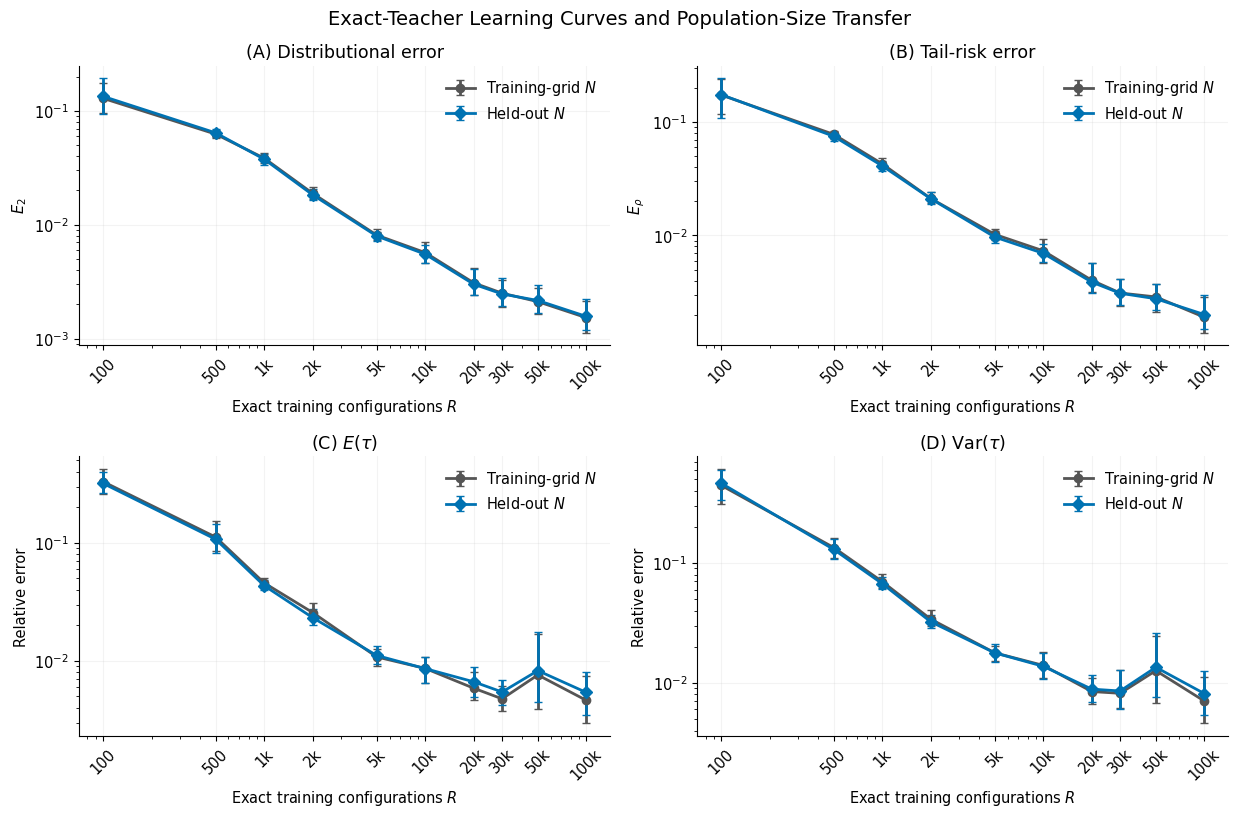


EXTRA LOW/MID R CELL COMPLETE
Combined R: (100, 500, 1000, 2000, 5000, 10000, 20000, 30000, 50000, 100000)

Outputs:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/full_numeric_summary_extra_lowR_combined.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/main_table_extra_lowR_combined.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/main_table_extra_lowR_combined.tex
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/raw_test_errors_extra_lowR_combined.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/transfer_penalty_extra_lowR_combined.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_1B_highR_JASA/run_20260823_083602/results/training_diagnostics_extra_lowR_combined.csv
/content/drive/MyDrive/StatisticalLearning/Experiment

In [3]:
# =====================================================================================
# EXTRA CELL — ADD LOW/MID R VALUES TO EXISTING EXPERIMENT
#
# Adds:
#   R = 100, 500, 1000, 2000, 5000, 10000
#
# Keeps:
#   existing results for R = 20000, 30000, 50000, 100000
#
# Requires that the main experiment cell has already been run or resumed.
# =====================================================================================

EXTRA_R_VALUES = (100, 500, 1000, 2000, 5000, 10000)

# Safety checks
required_objects = [
    "cfg", "train", "TEST_PACK", "TEST_RECORDS", "progress", "PROGRESS_FILE",
    "N_REP", "OUT", "MODELS", "CKPT", "pack", "fit", "evaluate",
    "balanced_order", "atomic_pickle", "METRICS", "BOOT_B"
]

missing = [x for x in required_objects if x not in globals()]

if missing:
    raise RuntimeError(
        "Missing objects from the main experiment cell:\n"
        + ", ".join(missing)
        + "\nRun/resume the main experiment cell first, then run this extra cell."
    )

assert max(EXTRA_R_VALUES) <= len(train), "Extra R exceeds available training pool."

print("\n" + "=" * 100)
print("ADDING EXTRA LOW/MID R VALUES")
print("=" * 100)
print("Extra R:", EXTRA_R_VALUES)
print("Existing high R:", globals().get("R_VALUES", None))
print("=" * 100)


# =====================================================================================
# 1. TRAIN + EVALUATE EXTRA R VALUES
# =====================================================================================

for rep in range(1, N_REP + 1):

    # Reuse the same balanced nested order if it already exists.
    if rep not in progress["orders"]:
        progress["orders"][rep] = balanced_order(
            train,
            cfg.seed + 20000 + rep * 1009
        )
        atomic_pickle(progress, PROGRESS_FILE)

    order = np.asarray(progress["orders"][rep], dtype=int)

    print("\n" + "=" * 90)
    print(f"EXTRA REPETITION {rep}/{N_REP}")
    print("=" * 90)

    for R in EXTRA_R_VALUES:

        key = f"rep{rep:02d}_R{R}"

        if key in progress["results"]:
            print(key, "| already complete — skipping")
            continue

        subset = [
            train[int(j)]
            for j in order[:R]
        ]

        counts = {
            N: sum(r.N == N for r in subset)
            for N in cfg.train_N
        }

        print(
            f"\nR={R:,} | "
            f"N-count range={min(counts.values())}-{max(counts.values())} | "
            f"i0=1={sum(r.i0 == 1 for r in subset) / R:.1%}"
        )

        TR = pack(subset)

        h, t, meta = fit(TR, rep, R)

        result = {}

        for split in ("seen", "interpolation"):
            result[split] = evaluate(
                h, t,
                TEST_PACK[split],
                TEST_RECORDS[split]
            )

        progress["results"][key] = {
            "rep": rep,
            "R": R,
            "seen": result["seen"],
            "interpolation": result["interpolation"],
            "training_sec": meta["training_sec"],
            "best_validation_loss": meta["best_validation_loss"],
            "best_epoch": meta["best_epoch"],
            "stopped_epoch": meta["stopped_epoch"],
            "n_tau_train": meta["n_tau_train"]
        }

        atomic_pickle(progress, PROGRESS_FILE)

        print(
            "Interpolation | "
            f"E2={np.nanmedian(result['interpolation']['E2']):.4e} | "
            f"E_rho={np.nanmedian(result['interpolation']['E_rho']):.4e} | "
            f"E(tau)={np.nanmedian(result['interpolation']['mean_tau_relative_error']):.4e} | "
            f"Var(tau)={np.nanmedian(result['interpolation']['var_tau_relative_error']):.4e}"
        )

        del TR, h, t

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# =====================================================================================
# 2. REBUILD COMBINED SUMMARY TABLE
# =====================================================================================

def available_for_all_reps(R):
    return all(
        f"rep{rep:02d}_R{R}" in progress["results"]
        for rep in range(1, N_REP + 1)
    )


COMBINED_R_VALUES = tuple(
    sorted(
        R for R in set(EXTRA_R_VALUES) | set(globals().get("R_VALUES", ()))
        if available_for_all_reps(R)
    )
)

print("\nAvailable combined R values:", COMBINED_R_VALUES)


def matrix_extra(R, split, metric):
    return np.vstack([
        progress["results"][f"rep{rep:02d}_R{R}"][split][metric]
        for rep in range(1, N_REP + 1)
    ])


def hier_ci_extra(A, B=BOOT_B, seed=1):
    A = np.asarray(A, float)
    nr, nc = A.shape
    rng = np.random.default_rng(seed)
    boot = []

    for _ in range(B):
        ir = rng.integers(0, nr, size=nr)
        ic = rng.integers(0, nc, size=nc)
        x = A[ir][:, ic]
        z = np.nanmedian(x)

        if np.isfinite(z):
            boot.append(z)

    boot = np.asarray(boot)

    return (
        float(np.quantile(boot, .025)),
        float(np.quantile(boot, .975))
    )


summary_extra = []

for R in COMBINED_R_VALUES:
    for split in ("seen", "interpolation"):
        for j, metric in enumerate(METRICS):

            A = matrix_extra(R, split, metric)
            x = A[np.isfinite(A)]

            lo, hi = hier_ci_extra(
                A,
                seed=cfg.seed + R + j + (
                    0 if split == "seen" else 50000
                )
            )

            summary_extra.append({
                "R": R,
                "split": split,
                "metric": metric,
                "median": float(np.median(x)),
                "q1": float(np.quantile(x, .25)),
                "q3": float(np.quantile(x, .75)),
                "p95": float(np.quantile(x, .95)),
                "CI_low": lo,
                "CI_high": hi,
                "n": len(x)
            })

summary_extra = pd.DataFrame(summary_extra)

summary_extra.to_csv(
    OUT / "full_numeric_summary_extra_lowR_combined.csv",
    index=False
)


# =====================================================================================
# 3. MAIN TABLE
# =====================================================================================

def S_extra(R, split, metric):
    return summary_extra[
        (summary_extra.R == R)
        &
        (summary_extra.split == split)
        &
        (summary_extra.metric == metric)
    ].iloc[0]


def F_extra(z):
    return (
        f"{z['median']:.4g} "
        f"[{z['CI_low']:.4g}, {z['CI_high']:.4g}]"
    )


table_extra = []

for R in COMBINED_R_VALUES:
    table_extra.append({
        "R": R,

        "Seen E2":
            F_extra(S_extra(R, "seen", "E2")),

        "Interpolation E2":
            F_extra(S_extra(R, "interpolation", "E2")),

        "Seen Erho":
            F_extra(S_extra(R, "seen", "E_rho")),

        "Interpolation Erho":
            F_extra(S_extra(R, "interpolation", "E_rho")),

        "Interpolation Rel E(tau)":
            F_extra(S_extra(R, "interpolation", "mean_tau_relative_error")),

        "Interpolation Rel Var(tau)":
            F_extra(S_extra(R, "interpolation", "var_tau_relative_error"))
    })

main_table_extra = pd.DataFrame(table_extra)

main_table_extra.to_csv(
    OUT / "main_table_extra_lowR_combined.csv",
    index=False
)

(
    OUT / "main_table_extra_lowR_combined.tex"
).write_text(
    main_table_extra.to_latex(
        index=False,
        escape=False
    )
)

print("\n" + "=" * 110)
print("COMBINED MAIN TABLE")
print("=" * 110)
print(main_table_extra.to_string(index=False))


# =====================================================================================
# 4. RAW TEST ERRORS
# =====================================================================================

raw_extra = []

for rep in range(1, N_REP + 1):
    for R in COMBINED_R_VALUES:
        key = f"rep{rep:02d}_R{R}"

        for split, records in TEST_RECORDS.items():

            z = progress["results"][key][split]

            for j, r in enumerate(records):

                row = {
                    "rep": rep,
                    "R": R,
                    "split": split,
                    "index": j,
                    "N": r.N,
                    "i0": r.i0,
                    "R0": r.beta / r.gamma
                }

                for metric in METRICS:
                    row[metric] = z[metric][j]

                raw_extra.append(row)

raw_extra = pd.DataFrame(raw_extra)

raw_extra.to_csv(
    OUT / "raw_test_errors_extra_lowR_combined.csv",
    index=False
)


# =====================================================================================
# 5. TRANSFER PENALTY
# =====================================================================================

def rep_boot_ci_extra(x, B=BOOT_B, seed=1):
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    z = np.empty(B)

    for b in range(B):
        z[b] = np.median(
            x[
                rng.integers(
                    0, len(x),
                    size=len(x)
                )
            ]
        )

    return (
        float(np.median(x)),
        float(np.quantile(z, .025)),
        float(np.quantile(z, .975))
    )


penalty_extra = []

for R in COMBINED_R_VALUES:
    for j, metric in enumerate((
        "E2",
        "E_rho",
        "mean_tau_relative_error",
        "var_tau_relative_error"
    )):

        d = []

        for rep in range(1, N_REP + 1):
            z = progress["results"][f"rep{rep:02d}_R{R}"]

            d.append(
                np.nanmedian(z["interpolation"][metric])
                -
                np.nanmedian(z["seen"][metric])
            )

        est, lo, hi = rep_boot_ci_extra(
            d,
            seed=cfg.seed + R + j
        )

        penalty_extra.append({
            "R": R,
            "metric": metric,
            "interpolation_minus_seen": est,
            "CI_low": lo,
            "CI_high": hi
        })

pd.DataFrame(penalty_extra).to_csv(
    OUT / "transfer_penalty_extra_lowR_combined.csv",
    index=False
)


# =====================================================================================
# 6. TRAINING DIAGNOSTICS
# =====================================================================================

training_extra = []

for rep in range(1, N_REP + 1):
    for R in COMBINED_R_VALUES:

        z = progress["results"][f"rep{rep:02d}_R{R}"]

        training_extra.append({
            "rep": rep,
            "R": R,
            "training_sec": z["training_sec"],
            "best_validation_loss": z["best_validation_loss"],
            "best_epoch": z["best_epoch"],
            "stopped_epoch": z["stopped_epoch"],
            "n_tau_train": z["n_tau_train"]
        })

pd.DataFrame(training_extra).to_csv(
    OUT / "training_diagnostics_extra_lowR_combined.csv",
    index=False
)


# =====================================================================================
# 7. COMBINED PUBLICATION FIGURE
# =====================================================================================

plt.rcParams.update({
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axs = plt.subplots(
    2, 2,
    figsize=(12.5, 8.3)
)

spec = [
    ("E2", r"$E_2$", "(A) Distributional error"),
    ("E_rho", r"$E_\rho$", "(B) Tail-risk error"),
    (
        "mean_tau_relative_error",
        "Relative error",
        r"(C) $E(\tau)$"
    ),
    (
        "var_tau_relative_error",
        "Relative error",
        r"(D) $\mathrm{Var}(\tau)$"
    )
]

def R_label(R):
    if R >= 1000:
        return f"{int(R/1000)}k"
    return str(R)

for ax, (metric, ylabel, title) in zip(
    axs.flat,
    spec
):

    for split, label, color, marker in (
        ("seen", "Training-grid $N$", "#555555", "o"),
        (
            "interpolation",
            "Held-out $N$",
            "#0072B2",
            "D"
        )
    ):

        med = []
        lo = []
        hi = []

        for R in COMBINED_R_VALUES:
            z = S_extra(R, split, metric)
            med.append(z["median"])
            lo.append(z["CI_low"])
            hi.append(z["CI_high"])

        med = np.asarray(med)
        lo = np.asarray(lo)
        hi = np.asarray(hi)

        ax.errorbar(
            COMBINED_R_VALUES,
            np.maximum(med, 1e-12),

            yerr=np.vstack([
                np.maximum(med - lo, 0),
                np.maximum(hi - med, 0)
            ]),

            color=color,
            marker=marker,
            lw=2,
            capsize=3,
            label=label
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(COMBINED_R_VALUES)
    ax.set_xticklabels(
        [R_label(R) for R in COMBINED_R_VALUES],
        rotation=45
    )

    ax.set_xlabel(
        r"Exact training configurations $R$"
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(alpha=.15)
    ax.legend(frameon=False)

fig.suptitle(
    "Exact-Teacher Learning Curves and Population-Size Transfer",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUT / "figure_extra_lowR_combined_main.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUT / "figure_extra_lowR_combined_main.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 8. CAPTION
# =====================================================================================

caption_extra = r"""
Predictive error as a function of the number \(R\) of exact Markovian training
configurations. Curves compare population sizes represented during training
with population sizes held out from teacher construction but lying within the
training population-size range. Points report median errors across independent
learning-curve repetitions and exact test configurations; error bars are 95\%
hierarchical bootstrap confidence intervals. The expanded grid includes
low- and mid-training sizes \(R=100,500,1000,2000,5000,10000\), together with
the previously computed high-\(R\) cases. Extinction-time errors are evaluated
only for configurations for which the exact sparse linear-system calculation
returned numerically admissible moment estimates.
""".strip()

(OUT / "figure_extra_lowR_combined_caption.txt").write_text(caption_extra)


# =====================================================================================
# 9. STATUS
# =====================================================================================

print("\n" + "=" * 100)
print("EXTRA LOW/MID R CELL COMPLETE")
print("=" * 100)

print("Combined R:", COMBINED_R_VALUES)

print("\nOutputs:")
print(OUT / "full_numeric_summary_extra_lowR_combined.csv")
print(OUT / "main_table_extra_lowR_combined.csv")
print(OUT / "main_table_extra_lowR_combined.tex")
print(OUT / "raw_test_errors_extra_lowR_combined.csv")
print(OUT / "transfer_penalty_extra_lowR_combined.csv")
print(OUT / "training_diagnostics_extra_lowR_combined.csv")
print(OUT / "figure_extra_lowR_combined_main.pdf")
print(OUT / "figure_extra_lowR_combined_main.png")
print(OUT / "figure_extra_lowR_combined_caption.txt")

print("=" * 100)